## Objective
This notebook focuses on customer segmentation using RFM analysis to identify high-value customers, examine revenue concentration, and uncover purchasing behavior patterns, with optional clustering for deeper insights.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## data preparation

In [34]:
customers = pd.read_csv("/content/drive/MyDrive/Olist_data/customers_clean.csv")
orders = pd.read_csv("/content/drive/MyDrive/Olist_data/orders_clean.csv")
items = pd.read_csv("/content/drive/MyDrive/Olist_data/items_clean.csv")
payments = pd.read_csv("/content/drive/MyDrive/Olist_data/payments_clean.csv")
reviews = pd.read_csv("/content/drive/MyDrive/Olist_data/reviews_clean.csv")
sellers = pd.read_csv("/content/drive/MyDrive/Olist_data/sellers_clean.csv")
products = pd.read_csv("/content/drive/MyDrive/Olist_data/products_clean.csv")
name_translations = pd.read_csv("/content/drive/MyDrive/Olist_data/name_translations_clean.csv")

In [35]:
orders_customers = pd.merge(orders, customers, on='customer_id', how='inner')
print("Merged 'orders' and 'customers' DataFrames. Displaying the first 5 rows:")
orders_customers.head()

Merged 'orders' and 'customers' DataFrames. Displaying the first 5 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [36]:
orders_customers_items = pd.merge(orders_customers, items, on='order_id', how='inner')
print("Merged 'orders_customers' and 'items' DataFrames. Displaying the first 5 rows:")
orders_customers_items.head()

Merged 'orders_customers' and 'items' DataFrames. Displaying the first 5 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [37]:
orders_customers_items['total_price'] = orders_customers_items['price'] + orders_customers_items['freight_value']
order_monetary = orders_customers_items.groupby('order_id')['total_price'].sum().reset_index()
order_monetary.rename(columns={'total_price': 'monetary'}, inplace=True)
print("Order monetary value calculated and displayed for the first 5 rows:")
order_monetary.head()

Order monetary value calculated and displayed for the first 5 rows:


,order_id,monetary
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [38]:
orders_customers['order_purchase_timestamp'] = pd.to_datetime(orders_customers['order_purchase_timestamp'])
last_order_date = orders_customers['order_purchase_timestamp'].max()
print(f"The most recent order date is: {last_order_date}")

The most recent order date is: 2018-08-29 15:00:37


In [39]:
orders_customers_items['order_purchase_timestamp'] = pd.to_datetime(orders_customers_items['order_purchase_timestamp'])
rfm_data = orders_customers_items.groupby('customer_unique_id').agg(
Recency=('order_purchase_timestamp', lambda date: (last_order_date - date.max()).days),Frequency=('order_id', 'nunique')).reset_index()
rfm_monetary = orders_customers_items.groupby('customer_unique_id')['total_price'].sum().reset_index()
rfm_monetary.rename(columns={'total_price': 'Monetary'}, inplace=True)
rfm_data = pd.merge(rfm_data, rfm_monetary, on='customer_unique_id', how='left')

In [40]:
rfm_data.head(10)

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19
2,0000f46a3911fa3c0805444483337064,536,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89
5,0004bd2a26a76fe21f786e4fbd80607f,145,1,166.98
6,00050ab1314c0e55a6ca13cf7181fecf,131,1,35.38
7,00053a61a98854899e70ed204dd4bafe,182,1,419.18
8,0005e1862207bf6ccc02e4228effd9a0,542,1,150.12
9,0005ef4cd20d2893f0d9fbd94d3c0d97,169,1,129.76


## RFM scoring [1 → 5]

In [41]:
rfm_data['R_Score'] = pd.qcut(rfm_data['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm_data.head(10)

,customer_unique_id,Recency,Frequency,Monetary,R_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,4
2,0000f46a3911fa3c0805444483337064,536,1,86.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62,2
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89,2
5,0004bd2a26a76fe21f786e4fbd80607f,145,1,166.98,4
6,00050ab1314c0e55a6ca13cf7181fecf,131,1,35.38,4
7,00053a61a98854899e70ed204dd4bafe,182,1,419.18,3
8,0005e1862207bf6ccc02e4228effd9a0,542,1,150.12,1
9,0005ef4cd20d2893f0d9fbd94d3c0d97,169,1,129.76,4


In [42]:
rfm_data['F_Score'] = pd.qcut(rfm_data['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm_data.head(10)

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,4,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,4,1
2,0000f46a3911fa3c0805444483337064,536,1,86.22,1,1
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62,2,1
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89,2,1
5,0004bd2a26a76fe21f786e4fbd80607f,145,1,166.98,4,1
6,00050ab1314c0e55a6ca13cf7181fecf,131,1,35.38,4,1
7,00053a61a98854899e70ed204dd4bafe,182,1,419.18,3,1
8,0005e1862207bf6ccc02e4228effd9a0,542,1,150.12,1,1
9,0005ef4cd20d2893f0d9fbd94d3c0d97,169,1,129.76,4,1


In [43]:
rfm_data['M_Score'] = pd.qcut(rfm_data['Monetary'], 5, labels=[1, 2, 3, 4, 5])
rfm_data.head(10)

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,4,1,1
2,0000f46a3911fa3c0805444483337064,536,1,86.22,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89,2,1,4
5,0004bd2a26a76fe21f786e4fbd80607f,145,1,166.98,4,1,4
6,00050ab1314c0e55a6ca13cf7181fecf,131,1,35.38,4,1,1
7,00053a61a98854899e70ed204dd4bafe,182,1,419.18,3,1,5
8,0005e1862207bf6ccc02e4228effd9a0,542,1,150.12,1,1,4
9,0005ef4cd20d2893f0d9fbd94d3c0d97,169,1,129.76,4,1,3


In [44]:
rfm_data['RFM_Score'] = rfm_data['R_Score'].astype(str) + rfm_data['F_Score'].astype(str) + rfm_data['M_Score'].astype(str)
rfm_data['RFM_Segment'] = rfm_data['R_Score'].astype(int) + rfm_data['F_Score'].astype(int) + rfm_data['M_Score'].astype(int)
rfm_data.head(10)

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,4,1,4,414,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,4,1,1,411,6
2,0000f46a3911fa3c0805444483337064,536,1,86.22,1,1,2,112,4
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62,2,1,1,211,4
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89,2,1,4,214,7
5,0004bd2a26a76fe21f786e4fbd80607f,145,1,166.98,4,1,4,414,9
6,00050ab1314c0e55a6ca13cf7181fecf,131,1,35.38,4,1,1,411,6
7,00053a61a98854899e70ed204dd4bafe,182,1,419.18,3,1,5,315,9
8,0005e1862207bf6ccc02e4228effd9a0,542,1,150.12,1,1,4,114,6
9,0005ef4cd20d2893f0d9fbd94d3c0d97,169,1,129.76,4,1,3,413,8


## identify high-value customers

In [47]:
segment_rules = [
    (rfm_data['RFM_Score'].str.startswith('55')) | (rfm_data['RFM_Score'].str.startswith('45')) | (rfm_data['RFM_Score'].str.startswith('54')), # Champions
    (rfm_data['RFM_Score'].str.startswith('35')) | (rfm_data['RFM_Score'].str.startswith('44')) | (rfm_data['RFM_Score'].str.startswith('34')) | (rfm_data['RFM_Score'].str.startswith('53')), # Loyal Customers
    (rfm_data['RFM_Score'].str.startswith('51')) | (rfm_data['RFM_Score'].str.startswith('41')) | (rfm_data['RFM_Score'].str.startswith('31')), # New Customers (High Recency, Low Frequency/Monetary)
    (rfm_data['RFM_Score'].str.startswith('1')) | (rfm_data['RFM_Score'].str.startswith('21')) | (rfm_data['RFM_Score'].str.startswith('22')), # At Risk (Low R, F, M)
    (rfm_data['RFM_Score'].str.startswith('32')) | (rfm_data['RFM_Score'].str.startswith('23')) | (rfm_data['RFM_Score'].str.startswith('33')), # Needs Attention
    (rfm_data['RFM_Score'].str.startswith('43')) | (rfm_data['RFM_Score'].str.startswith('42')) | (rfm_data['RFM_Score'].str.startswith('52')) # Promising
]
segment_labels = ['Champions','Loyal Customers','New Customers','At Risk','Needs Attention','Promising']
rfm_data['Customer_Segment'] = np.select(segment_rules, segment_labels, default='Other')

In [48]:
rfm_data['Customer_Segment'].value_counts()

,count
Customer_Segment,
At Risk,26052
Loyal Customers,14927
Champions,11358
Promising,11246
New Customers,11186
Needs Attention,11140
Other,7427


In [50]:
rfm_data.head(10)

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,Customer_Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,4,1,4,414,9,New Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,4,1,1,411,6,New Customers
2,0000f46a3911fa3c0805444483337064,536,1,86.22,1,1,2,112,4,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62,2,1,1,211,4,At Risk
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89,2,1,4,214,7,At Risk
5,0004bd2a26a76fe21f786e4fbd80607f,145,1,166.98,4,1,4,414,9,New Customers
6,00050ab1314c0e55a6ca13cf7181fecf,131,1,35.38,4,1,1,411,6,New Customers
7,00053a61a98854899e70ed204dd4bafe,182,1,419.18,3,1,5,315,9,New Customers
8,0005e1862207bf6ccc02e4228effd9a0,542,1,150.12,1,1,4,114,6,At Risk
9,0005ef4cd20d2893f0d9fbd94d3c0d97,169,1,129.76,4,1,3,413,8,New Customers


## revenue concentration analysis

*   Top 10% customers revenue
*   Top 10% customers revenue



In [55]:
rfm_data = rfm_data.sort_values(by='Monetary', ascending=False)
rfm_data.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,Customer_Segment,Cumulative_Monetary,Cumulative_Monetary_Percentage
3724,0a0a92112bd4c708ca5fde585afaa872,333,1,13664.08,2,1,5,215,8,At Risk,13664.08,0.088634
79617,da122df9eeddfedc1dc1f5349a1a690c,514,2,7571.63,1,5,5,155,11,At Risk,21235.71,0.137749
43161,763c8b1c9c68a0229c42c9fc6f662b93,45,1,7274.88,5,3,5,535,13,Loyal Customers,28510.59,0.184939
80444,dc4802a71eae9be1dd28f5d788ceb526,562,1,6929.31,1,5,5,155,11,At Risk,35439.90,0.229887
25431,459bef486812aa25204be022145caa62,34,1,6922.21,5,2,5,525,12,Promising,42362.11,0.274789


In [52]:
rfm_data['Cumulative_Monetary'] = rfm_data['Monetary'].cumsum()
print("Cumulative monetary value calculated. Displaying the first 5 rows with the new column:")
rfm_data.head()

Cumulative monetary value calculated. Displaying the first 5 rows with the new column:


,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,Customer_Segment,Cumulative_Monetary
3724,0a0a92112bd4c708ca5fde585afaa872,333,1,13664.08,2,1,5,215,8,At Risk,13664.08
79617,da122df9eeddfedc1dc1f5349a1a690c,514,2,7571.63,1,5,5,155,11,At Risk,21235.71
43161,763c8b1c9c68a0229c42c9fc6f662b93,45,1,7274.88,5,3,5,535,13,Loyal Customers,28510.59
80444,dc4802a71eae9be1dd28f5d788ceb526,562,1,6929.31,1,5,5,155,11,At Risk,35439.90
25431,459bef486812aa25204be022145caa62,34,1,6922.21,5,2,5,525,12,Promising,42362.11


In [56]:
total_monetary = rfm_data['Monetary'].sum()
rfm_data['Cumulative_Monetary_Percentage'] = (rfm_data['Cumulative_Monetary'] / total_monetary) * 100
rfm_data.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,Customer_Segment,Cumulative_Monetary,Cumulative_Monetary_Percentage
3724,0a0a92112bd4c708ca5fde585afaa872,333,1,13664.08,2,1,5,215,8,At Risk,13664.08,0.088634
79617,da122df9eeddfedc1dc1f5349a1a690c,514,2,7571.63,1,5,5,155,11,At Risk,21235.71,0.137749
43161,763c8b1c9c68a0229c42c9fc6f662b93,45,1,7274.88,5,3,5,535,13,Loyal Customers,28510.59,0.184939
80444,dc4802a71eae9be1dd28f5d788ceb526,562,1,6929.31,1,5,5,155,11,At Risk,35439.90,0.229887
25431,459bef486812aa25204be022145caa62,34,1,6922.21,5,2,5,525,12,Promising,42362.11,0.274789


In [57]:
top_10_percent_customers = rfm_data[rfm_data['Cumulative_Monetary_Percentage'] <= 10]
print("Customers contributing to the top 10% of total revenue:\n")
top_10_percent_customers[['customer_unique_id', 'Monetary', 'Cumulative_Monetary_Percentage']].head()

Customers contributing to the top 10% of total revenue:



,customer_unique_id,Monetary,Cumulative_Monetary_Percentage
3724,0a0a92112bd4c708ca5fde585afaa872,13664.08,0.088634
79617,da122df9eeddfedc1dc1f5349a1a690c,7571.63,0.137749
43161,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,0.184939
80444,dc4802a71eae9be1dd28f5d788ceb526,6929.31,0.229887
25431,459bef486812aa25204be022145caa62,6922.21,0.274789


## some visualizations

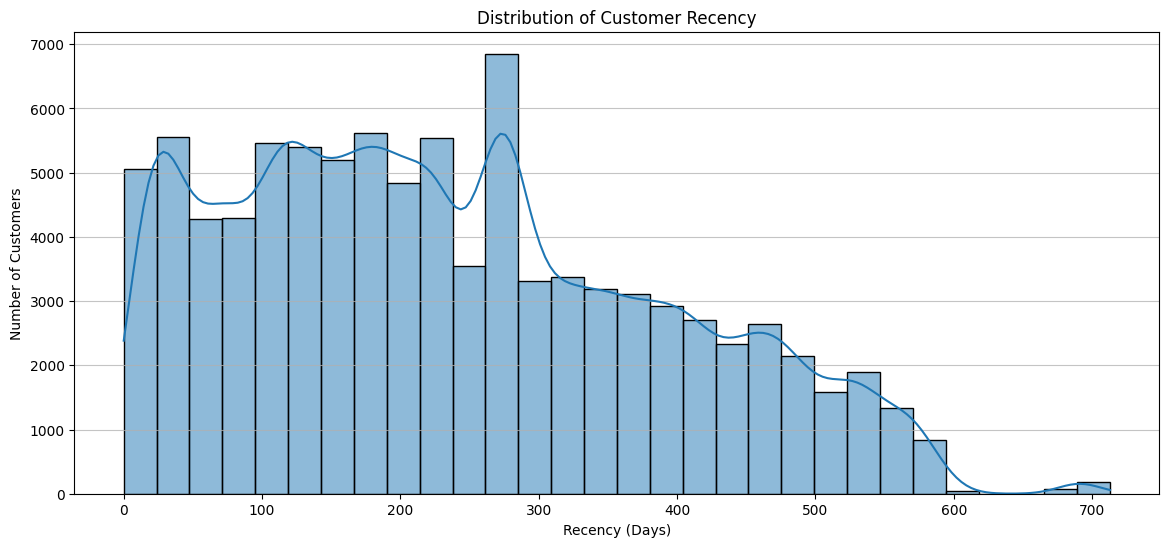

In [64]:
plt.figure(figsize=(14, 6))
sns.histplot(rfm_data['Recency'], bins=30, kde=True)
plt.title('Distribution of Customer Recency')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)
plt.show()

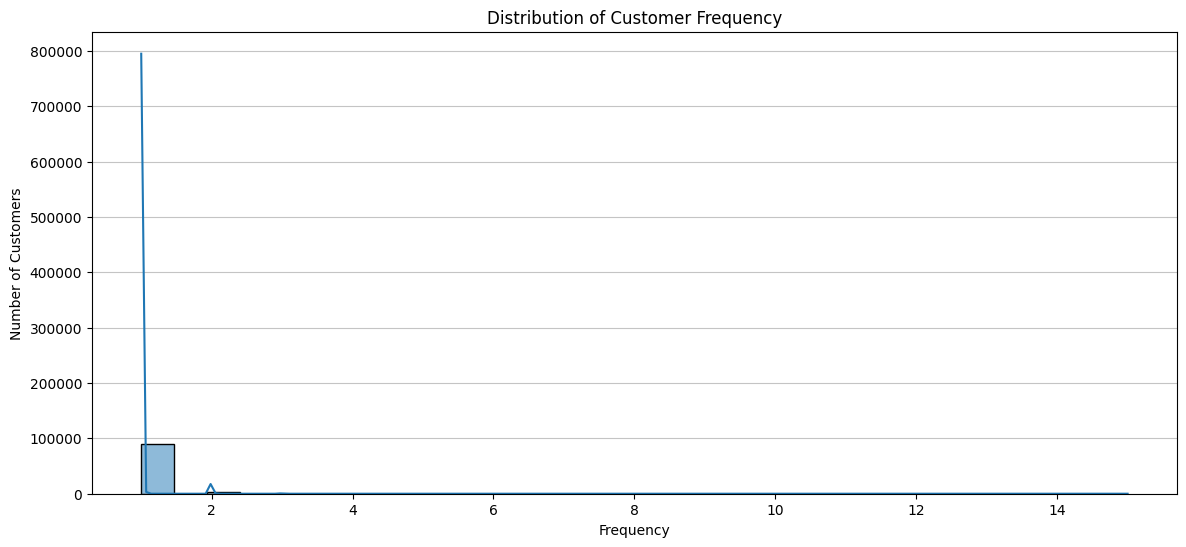

In [65]:
plt.figure(figsize=(14, 6))
sns.histplot(rfm_data['Frequency'], bins=30, kde=True)
plt.title('Distribution of Customer Frequency')
plt.xlabel('Frequency')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)
plt.show()

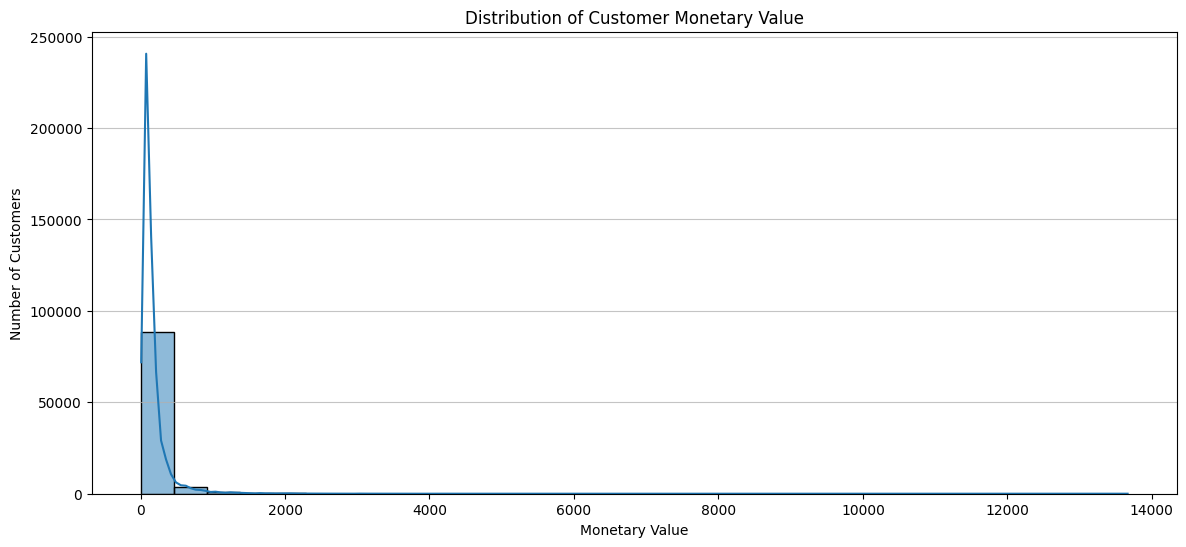

In [66]:
plt.figure(figsize=(14, 6))
sns.histplot(rfm_data['Monetary'], bins=30, kde=True)
plt.title('Distribution of Customer Monetary Value')
plt.xlabel('Monetary Value')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)
plt.show()

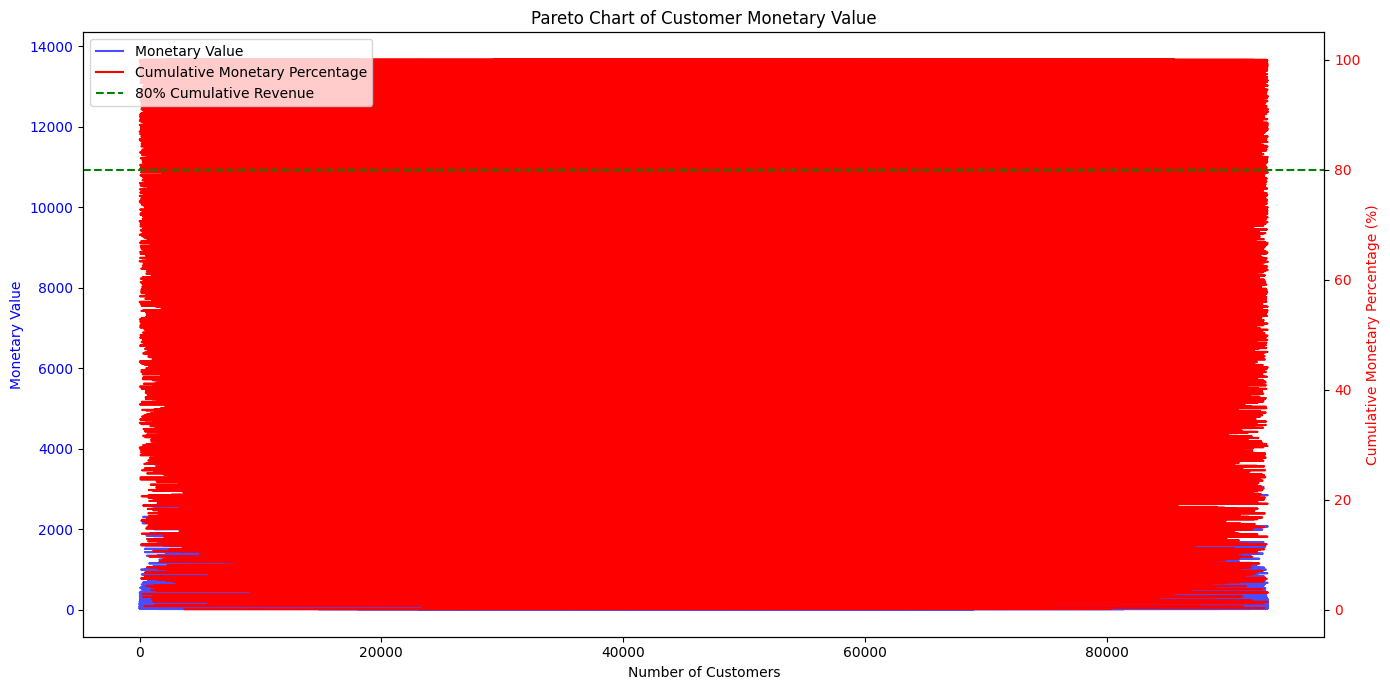

In [71]:
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.plot(rfm_data.index, rfm_data['Monetary'], color='blue', alpha=0.7, label='Monetary Value')
ax1.set_xlabel('Number of Customers')
ax1.set_ylabel('Monetary Value', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
ax2.plot(rfm_data.index, rfm_data['Cumulative_Monetary_Percentage'], color='red', label='Cumulative Monetary Percentage')
ax2.set_ylabel('Cumulative Monetary Percentage (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(y=80, color='green', linestyle='--', label='80% Cumulative Revenue')
plt.title('Pareto Chart of Customer Monetary Value')
fig.tight_layout()
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.show()

## Final Key Takeaways

### Customer Segmentation (RFM)
- **Champions**: Recent, frequent, and highest-spending customers.
- **Loyal Customers**: Consistent buyers with strong spending.
- **New Customers**: Recent buyers with low purchase history.
- **Promising**: Recent spenders with potential to become loyal.
- **Needs Attention**: Previously active customers who may disengage.
- **At Risk**: Inactive customers with high churn probability.

### Revenue Concentration
- A small portion of customers (≈10%) generates a large share of total revenue, reflecting the **Pareto principle (80/20 rule)**.

### Overall Insight
- **RFM segmentation** helps businesses understand customer behavior, target marketing strategies, and focus on high-value customers to increase retention and lifetime value.